In [1]:
from google.colab import files
uploaded = files.upload()

Saving val_idx.txt to val_idx.txt
Saving train_idx.txt to train_idx.txt
Saving test_idx.txt to test_idx.txt


In [2]:
from datasets import load_dataset
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

dataset = load_dataset("Tobi-Bueck/customer-support-tickets", split="train")
df = dataset.to_pandas()


train_idx = pd.read_csv("train_idx.txt", header=None)[0].tolist()

train_df = df.iloc[train_idx]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

In [3]:
val_idx = pd.read_csv("val_idx.txt", header=None)[0].tolist()
test_idx = pd.read_csv("test_idx.txt", header=None)[0].tolist()

val_df = df.iloc[val_idx]
test_df = df.iloc[test_idx]

In [4]:
train_df

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61760,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,I would be happy to assist with the IFTTT Dock...,Problem,Technical Support,low,en,NaN,Integration,Disruption,Performance,IT,Tech Support,None,None,None
61761,Bitten um Unterstützung bei der Integration,"Sehr geehrte Kundenservice, ich möchte die Int...","Sehr geehrte [Name], vielen Dank für Ihren Kon...",Change,Technical Support,medium,de,NaN,Integration,Feature,Documentation,Tech Support,None,None,None,None
61762,None,"Hello Customer Support, I am inquiring about t...",We will send you detailed information on plans...,Request,Billing and Payments,low,en,NaN,Billing,Payment,Feature,Feedback,Sales,Lead,None,None
61763,Hilfe bei digitalen Strategie-Problemen,Die Qualität unserer digitalen Strategie-Bearb...,Um den digitalen Strategie-Impuls zu überprüfe...,Incident,Product Support,high,de,NaN,Feedback,Performance,IT,Tech Support,None,None,None,None


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49412 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   45144 non-null  object 
 1   body      49410 non-null  object 
 2   answer    38893 non-null  object 
 3   type      38904 non-null  object 
 4   queue     49412 non-null  object 
 5   priority  49412 non-null  object 
 6   language  49412 non-null  object 
 7   version   22924 non-null  float64
 8   tag_1     38904 non-null  object 
 9   tag_2     38857 non-null  object 
 10  tag_3     38722 non-null  object 
 11  tag_4     35212 non-null  object 
 12  tag_5     22118 non-null  object 
 13  tag_6     10580 non-null  object 
 14  tag_7     4757 non-null   object 
 15  tag_8     1981 non-null   object 
dtypes: float64(1), object(15)
memory usage: 6.4+ MB


In [6]:
train_df.isnull().sum()

,0
subject,4268
body,2
answer,10519
type,10508
queue,0
priority,0
language,0
version,26488
tag_1,10508
tag_2,10555


In [4]:
# заполняю пропуски
train_df = train_df.copy()
train_df["subject"] = train_df["subject"].fillna("")
train_df["body"] = train_df["body"].fillna("")
train_df["type"] = train_df["type"].fillna("Unknown")

In [8]:
train_df.isnull().sum()

,0
subject,0
body,0
answer,10519
type,0
queue,0
priority,0
language,0
version,26488
tag_1,10508
tag_2,10555


In [9]:
train_df["language"].describe()
# английский и немецкий почти в равных пропорциях

,language
count,49412
unique,2
top,de
freq,26799


In [5]:
# необходимые по заданию фичи
train_df = train_df[[
    "subject",
    "body",
    "queue",
    "priority",
    "type"
]]

In [6]:
train_df.loc[:, "text"] = train_df["subject"] + " " + train_df["body"]

In [12]:
train_df["queue"].value_counts()

,count
queue,
Technical Support,11354
Product Support,7139
Customer Service,5905
IT Support,4673
Billing and Payments,3853
Returns and Exchanges,1956
Service Outages and Maintenance,1534
Sales and Pre-Sales,1228
Human Resources,730


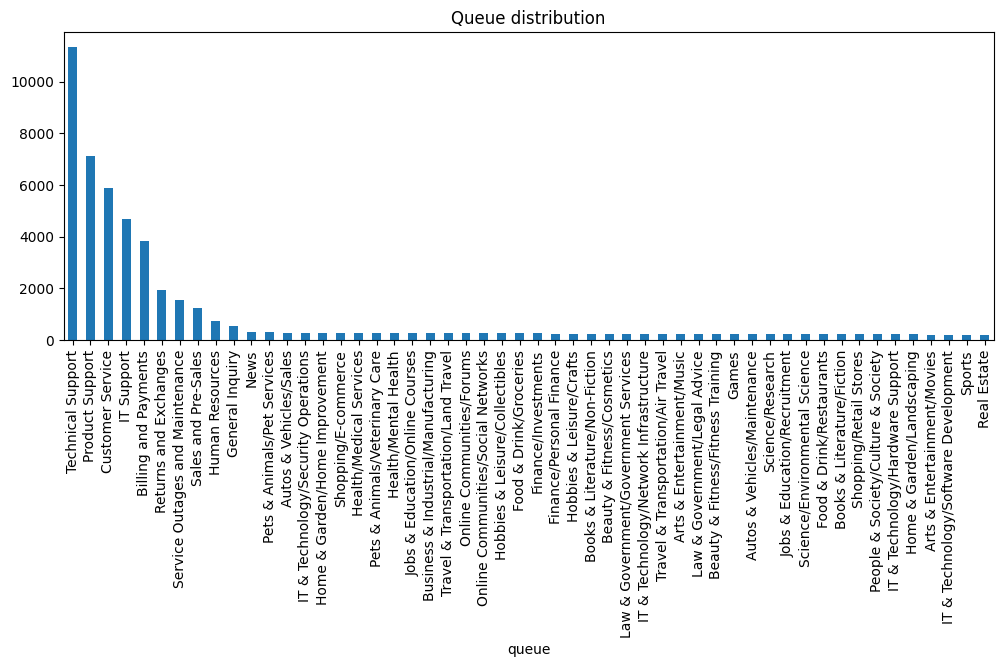

In [7]:
import matplotlib.pyplot as plt
#классовый дисбаланс
train_df["queue"].value_counts().plot(kind="bar", figsize=(12,4))
plt.title("Queue distribution")
plt.show()

In [14]:
train_df["priority"].value_counts()

,count
priority,
medium,18629
high,17546
low,10280
critical,1516
very_low,1441


In [8]:
train_df["text_length"] = train_df["text"].apply(len)
train_df["text_length"].describe()

,text_length
count,49412.000000
mean,463.754635
std,226.844163
min,5.000000
25%,279.000000
50%,459.000000
75%,633.000000
max,2284.000000


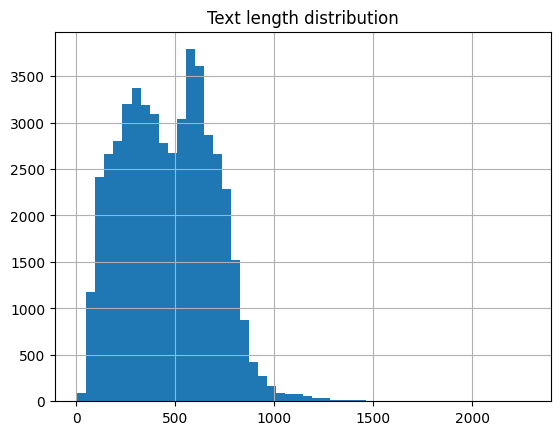

In [10]:
train_df["text_length"].hist(bins=50)
plt.title("Text length distribution")
plt.show()

In [17]:
train_df.sample(5)[["text","queue","priority","type"]]

,text,queue,priority,type
15269,Problem with MATLAB Crash MATLAB encountered a...,Product Support,high,Problem
21152,Support Required for Zapier Integration Hello ...,Customer Service,low,Request
44750,"Fehler bei den Anlagen-Daten, die nicht korrek...",Technical Support,low,Problem
16385,WLAN-Verbindungsprobleme Support Anfrage Betre...,Technical Support,high,Incident
11637,Details on Scalability Features for Project Ma...,Customer Service,medium,Request


In [18]:
train_df["text"].duplicated().sum()

np.int64(6663)

In [19]:
train_df.groupby("text")["queue"].nunique().sort_values(ascending=False).head()

,queue
text,
"Überwachung medizinischer Daten in Krankenhaus-Systemen Sehr geehrte Kundensupport, könnten Sie mir detaillierte Informationen über Lösungen zur Überwachung medizinischer Daten in Krankenhaus-IT-Systemen geben? Ich möchte gerne mehr über Maßnahmen erfahren, um vertrauliche Patientendaten zu schützen. Insbesondere interessieren mich die Verwendung von Verschlüsselungsverfahren, Zugangskontrollen und Datensicherungsprozeduren. Vielen Dank für Ihre Unterstützung.",1
"geehrte Kundenservice, könnten Sie mir zusätzliche Informationen zu digitalen Strategien zur Förderung des Markenwachstums geben? Ich freue mich darauf, konkrete Maßnahmen zu erfahren, die wir nutzen können, um die Markenbewusstheit und das Engagement zu steigern. Könnten Sie mir empfehlenswerte Werkzeuge und Plattformen nennen? Ich bedanke mich im Voraus für Ihre Unterstützung und freue mich auf eine Rückmeldung.",1
"needing support. there was an incident involving unauthorized access to medical data. system updates were implemented and user training provided, but access issues still persist.",1
"15. Oktober zeigten sich Störungen bei Design- und Automatisierungsprozessen, wobei Figma und Zapier unzugänglich waren. Obwohl die Geräte neu gestartet und die Internetverbindung überprüft wurde, sowie versucht wurde, beeinträchtigende Anwendungen neu zu installieren, bestehen die Probleme weiterhin. Die neuesten Softwareupdates werden als Folge von Misskonfigurationen auf Apple MacBook Air zurückgeführt. Wir benötigen Ihre Unterstützung, um das Problem zu beheben und die Prozesse wiederherzustellen.",1
"A billing discrepancy has arisen on Adobe Effects GitHub following the latest system update. Despite attempts to reconcile the account and contacting customer service, a resolution has not been reached. Assistance is required to address this issue.",1


In [22]:
train_df

,subject,body,queue,priority,type,text,text_length,token_length
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support,high,Incident,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...,783,84
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,"Account Disruption Dear Customer Support Team,...",563,84
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,Query About Smart Home System Integration Feat...,585,83
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,Inquiry Regarding Invoice Details Dear Custome...,639,95
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,Question About Marketing Agency Software Compa...,732,103
...,...,...,...,...,...,...,...,...
61760,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,Technical Support,low,Problem,Assistance Needed for IFTTT Docker Integration...,336,52
61761,Bitten um Unterstützung bei der Integration,"Sehr geehrte Kundenservice, ich möchte die Int...",Technical Support,medium,Change,Bitten um Unterstützung bei der Integration Se...,584,71
61762,,"Hello Customer Support, I am inquiring about t...",Billing and Payments,low,Request,"Hello Customer Support, I am inquiring about ...",606,91
61763,Hilfe bei digitalen Strategie-Problemen,Die Qualität unserer digitalen Strategie-Bearb...,Product Support,high,Incident,Hilfe bei digitalen Strategie-Problemen Die Qu...,482,62


In [9]:
val_df = val_df.copy()
val_df["subject"] = val_df["subject"].fillna("")
val_df["body"] = val_df["body"].fillna("")
val_df["type"] = val_df["type"].fillna("Unknown")
val_df = val_df[[
    "subject",
    "body",
    "queue",
    "priority",
    "type"
]]
val_df.loc[:, "text"] = val_df["subject"] + " " + val_df["body"]
val_df["text_length"] = val_df["text"].apply(len)

In [10]:
X_train = train_df["text"]
y_train = train_df["queue"]

X_val = val_df["text"]
y_val = val_df["queue"]

In [25]:
# выбираю Baseline: TF-IDF + линейная модель для queue
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )),
        ("clf", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    macro_f1 = f1_score(y_val, y_pred, average="macro")
    acc = accuracy_score(y_val, y_pred)

    return {
        "model": model_name,
        "macro_f1": macro_f1,
        "accuracy": acc
    }

In [26]:
results = []

results.append(
    evaluate_model(
        LogisticRegression(max_iter=1000, n_jobs=-1, class_weight="balanced"),
        X_train, y_train, X_val, y_val,
        "TF-IDF + LogisticRegression"
    )
)

results.append(
    evaluate_model(
        LinearSVC(class_weight="balanced"),
        X_train, y_train, X_val, y_val,
        "TF-IDF + LinearSVC"
    )
)

results.append(
    evaluate_model(
        MultinomialNB(),
        X_train, y_train, X_val, y_val,
        "TF-IDF + MultinomialNB"
    )
)

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
results_df
# лучшая TF-IDF + LinearSVC

,model,macro_f1,accuracy
1,TF-IDF + LinearSVC,0.858425,0.617228
0,TF-IDF + LogisticRegression,0.804729,0.494981
2,TF-IDF + MultinomialNB,0.430710,0.398154


Сначала пробую SentenceTransformer + LogisticRegression на на multitask

In [16]:
from sentence_transformers import SentenceTransformer

In [17]:
# модель эмбеддингов
st_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# эмбеддинги
X_train_emb = st_model.encode(
    train_df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

X_val_emb = st_model.encode(
    val_df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

# target
y_train_queue = train_df["queue"]
y_val_queue = val_df["queue"]

clf_queue = LogisticRegression(
    max_iter=2000,
    n_jobs=-1
)

clf_queue.fit(X_train_emb, y_train_queue)
pred_queue = clf_queue.predict(X_val_emb)

macro_f1 = f1_score(y_val_queue, pred_queue, average="macro")
acc = accuracy_score(y_val_queue, pred_queue)

y_train_priority = train_df["priority"]
y_val_priority = val_df["priority"]

y_train_type = train_df["type"]
y_val_type = val_df["type"]

clf_priority = LogisticRegression(max_iter=2000, n_jobs=-1)
clf_type = LogisticRegression(max_iter=2000, n_jobs=-1)

clf_priority.fit(X_train_emb, y_train_priority)
clf_type.fit(X_train_emb, y_train_type)

pred_priority = clf_priority.predict(X_val_emb)
pred_type = clf_type.predict(X_val_emb)

acc_priority = accuracy_score(y_val_priority, pred_priority)
acc_type = accuracy_score(y_val_type, pred_type)

score = 0.70 * macro_f1 + 0.15 * acc_priority + 0.15 * acc_type

print(f"SentenceTransformer + LogisticRegression")
print(f"Macro-F1(queue): {macro_f1:.4f}")
print(f"Accuracy(queue): {acc:.4f}")
print(f"Accuracy(priority): {acc_priority:.4f}")
print(f"Accuracy(type): {acc_type:.4f}")
print(f"Score: {score:.4f}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/773 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

SentenceTransformer + LogisticRegression
Macro-F1(queue): 0.7857
Accuracy(queue): 0.5329
Accuracy(priority): 0.5343
Accuracy(type): 0.8342
Score: 0.7552


Меньше чем в baseline


mBERT

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
queue_le = LabelEncoder()
priority_le = LabelEncoder()
type_le = LabelEncoder()

train_df = train_df.copy()
val_df = val_df.copy()

train_df["queue_id"] = queue_le.fit_transform(train_df["queue"])
val_df["queue_id"] = queue_le.transform(val_df["queue"])

train_df["priority_id"] = priority_le.fit_transform(train_df["priority"])
val_df["priority_id"] = priority_le.transform(val_df["priority"])

train_df["type_id"] = type_le.fit_transform(train_df["type"])
val_df["type_id"] = type_le.transform(val_df["type"])

num_queue = len(queue_le.classes_)
num_priority = len(priority_le.classes_)
num_type = len(type_le.classes_)

print(num_queue, num_priority, num_type)

52 5 5


In [29]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

In [30]:
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
MAX_LEN = 256

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [31]:
class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts = df["text"].tolist()
        self.queue = df["queue_id"].tolist()
        self.priority = df["priority_id"].tolist()
        self.type_ = df["type_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels_queue"] = torch.tensor(self.queue[idx], dtype=torch.long)
        item["labels_priority"] = torch.tensor(self.priority[idx], dtype=torch.long)
        item["labels_type"] = torch.tensor(self.type_[idx], dtype=torch.long)
        return item

In [32]:
train_dataset = TicketDataset(train_df, tokenizer, MAX_LEN)
val_dataset = TicketDataset(val_df, tokenizer, MAX_LEN)

In [33]:
import torch.nn as nn
from transformers import AutoModel

In [34]:
class MultitaskClassifier(nn.Module):
    def __init__(self, model_name, num_queue, num_priority, num_type, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.queue_head = nn.Linear(hidden_size, num_queue)
        self.priority_head = nn.Linear(hidden_size, num_priority)
        self.type_head = nn.Linear(hidden_size, num_type)

    def forward(self, input_ids, attention_mask, labels_queue=None, labels_priority=None, labels_type=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]

        pooled = self.dropout(pooled)

        logits_queue = self.queue_head(pooled)
        logits_priority = self.priority_head(pooled)
        logits_type = self.type_head(pooled)

        loss = None
        if labels_queue is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss_queue = loss_fct(logits_queue, labels_queue)
            loss_priority = loss_fct(logits_priority, labels_priority)
            loss_type = loss_fct(logits_type, labels_type)

            loss = loss_queue + loss_priority + loss_type

        return {
            "loss": loss,
            "logits_queue": logits_queue,
            "logits_priority": logits_priority,
            "logits_type": logits_type
        }

In [35]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [36]:
model = MultitaskClassifier(
    model_name=model_name,
    num_queue=num_queue,
    num_priority=num_priority,
    num_type=num_type
)

model = model.to(DEVICE)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [37]:
import torch
from torch.utils.data import DataLoader

BATCH_SIZE_TRAIN = 8
BATCH_SIZE_VAL = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_VAL, shuffle=False)

In [38]:
def move_batch_to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}

In [39]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

In [40]:
from tqdm.auto import tqdm

EPOCHS = 1

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    progress_bar = tqdm(train_loader, desc=f"Train epoch {epoch+1}")

    for batch in progress_bar:
        batch = move_batch_to_device(batch, DEVICE)

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels_queue=batch["labels_queue"],
            labels_priority=batch["labels_priority"],
            labels_type=batch["labels_type"],
        )

        loss = outputs["loss"]
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    print(f"Epoch {epoch+1} mean train loss: {sum(train_losses)/len(train_losses):.4f}")

Train epoch 1:   0%|          | 0/6177 [00:00<?, ?it/s]

Epoch 1 mean train loss: 3.6033


In [41]:
import numpy as np

In [42]:
model.eval()

all_queue_preds = []
all_priority_preds = []
all_type_preds = []

all_queue_true = []
all_priority_true = []
all_type_true = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validation"):
        all_queue_true.extend(batch["labels_queue"].numpy())
        all_priority_true.extend(batch["labels_priority"].numpy())
        all_type_true.extend(batch["labels_type"].numpy())

        batch = move_batch_to_device(batch, DEVICE)

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        queue_preds = torch.argmax(outputs["logits_queue"], dim=1).cpu().numpy()
        priority_preds = torch.argmax(outputs["logits_priority"], dim=1).cpu().numpy()
        type_preds = torch.argmax(outputs["logits_type"], dim=1).cpu().numpy()

        all_queue_preds.extend(queue_preds)
        all_priority_preds.extend(priority_preds)
        all_type_preds.extend(type_preds)

macro_f1_queue = f1_score(all_queue_true, all_queue_preds, average="macro")
acc_queue = accuracy_score(all_queue_true, all_queue_preds)
acc_priority = accuracy_score(all_priority_true, all_priority_preds)
acc_type = accuracy_score(all_type_true, all_type_preds)

score = (
    0.70 * macro_f1_queue +
    0.15 * acc_priority +
    0.15 * acc_type
)

print(f"Macro-F1(queue): {macro_f1_queue:.4f}")
print(f"Accuracy(queue): {acc_queue:.4f}")
print(f"Accuracy(priority): {acc_priority:.4f}")
print(f"Accuracy(type): {acc_type:.4f}")
print(f"Validation Score: {score:.4f}")

Validation:   0%|          | 0/386 [00:00<?, ?it/s]

Macro-F1(queue): 0.1867
Accuracy(queue): 0.3721
Accuracy(priority): 0.5468
Accuracy(type): 0.8459
Validation Score: 0.3396


Сильно хуже baseline, попробую сменить модель и настроить под данные

In [11]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

# =========================
# Config
# =========================
MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 192
TRAIN_SAMPLE_SIZE = 6000
VAL_SAMPLE_SIZE = 1000
BATCH_SIZE_TRAIN = 8
BATCH_SIZE_VAL = 16
EPOCHS = 1
LR = 2e-5

# =========================
# Label encoding
# =========================
queue_le = LabelEncoder()
priority_le = LabelEncoder()
type_le = LabelEncoder()

train_df = train_df.copy()
val_df = val_df.copy()

train_df["queue_id"] = queue_le.fit_transform(train_df["queue"])
val_df["queue_id"] = queue_le.transform(val_df["queue"])

train_df["priority_id"] = priority_le.fit_transform(train_df["priority"])
val_df["priority_id"] = priority_le.transform(val_df["priority"])

train_df["type_id"] = type_le.fit_transform(train_df["type"])
val_df["type_id"] = type_le.transform(val_df["type"])

num_queue = len(queue_le.classes_)
num_priority = len(priority_le.classes_)
num_type = len(type_le.classes_)

print("num_queue:", num_queue)
print("num_priority:", num_priority)
print("num_type:", num_type)

# =========================
# Fast subsets
# =========================
train_df_fast = train_df.sample(TRAIN_SAMPLE_SIZE, random_state=42).copy()
val_df_fast = val_df.sample(VAL_SAMPLE_SIZE, random_state=42).copy()

print(train_df_fast.shape, val_df_fast.shape)

# =========================
# Tokenizer
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# =========================
# Dataset
# =========================
class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = df["text"].tolist()
        self.queue = df["queue_id"].tolist()
        self.priority = df["priority_id"].tolist()
        self.type_ = df["type_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels_queue"] = torch.tensor(self.queue[idx], dtype=torch.long)
        item["labels_priority"] = torch.tensor(self.priority[idx], dtype=torch.long)
        item["labels_type"] = torch.tensor(self.type_[idx], dtype=torch.long)
        return item

train_dataset_fast = TicketDataset(train_df_fast, tokenizer, MAX_LEN)
val_dataset_fast = TicketDataset(val_df_fast, tokenizer, MAX_LEN)

train_loader_fast = DataLoader(train_dataset_fast, batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader_fast = DataLoader(val_dataset_fast, batch_size=BATCH_SIZE_VAL, shuffle=False)

# =========================
# Model
# =========================
class MultitaskXLMR(nn.Module):
    def __init__(self, model_name, num_queue, num_priority, num_type, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.queue_head = nn.Linear(hidden_size, num_queue)
        self.priority_head = nn.Linear(hidden_size, num_priority)
        self.type_head = nn.Linear(hidden_size, num_type)

    def forward(self, input_ids, attention_mask, labels_queue=None, labels_priority=None, labels_type=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)

        logits_queue = self.queue_head(pooled)
        logits_priority = self.priority_head(pooled)
        logits_type = self.type_head(pooled)

        loss = None
        if labels_queue is not None:
            loss_fct = nn.CrossEntropyLoss()

            loss_queue = loss_fct(logits_queue, labels_queue)
            loss_priority = loss_fct(logits_priority, labels_priority)
            loss_type = loss_fct(logits_type, labels_type)

            loss = 3.0 * loss_queue + 1.0 * loss_priority + 1.0 * loss_type

        return {
            "loss": loss,
            "logits_queue": logits_queue,
            "logits_priority": logits_priority,
            "logits_type": logits_type
        }


num_queue: 52
num_priority: 5
num_type: 5
(6000, 10) (1000, 10)


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
model_fast = MultitaskXLMR(
    model_name=MODEL_NAME,
    num_queue=num_queue,
    num_priority=num_priority,
    num_type=num_type
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

model_fast = model_fast.to(DEVICE)
optimizer = AdamW(model_fast.parameters(), lr=LR)

def move_batch_to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}


Device: cuda


In [14]:
for epoch in range(EPOCHS):
    model_fast.train()
    train_losses = []

    progress_bar = tqdm(train_loader_fast, desc=f"Train epoch {epoch+1}")

    for batch in progress_bar:
        batch = move_batch_to_device(batch, DEVICE)

        optimizer.zero_grad()

        outputs = model_fast(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels_queue=batch["labels_queue"],
            labels_priority=batch["labels_priority"],
            labels_type=batch["labels_type"],
        )

        loss = outputs["loss"]
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    print(f"Epoch {epoch+1} mean train loss: {sum(train_losses)/len(train_losses):.4f}")

Train epoch 1:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1 mean train loss: 10.3851


In [15]:
model_fast.eval()

all_queue_preds = []
all_priority_preds = []
all_type_preds = []

all_queue_true = []
all_priority_true = []
all_type_true = []

with torch.no_grad():
    for batch in tqdm(val_loader_fast, desc="Validation"):
        all_queue_true.extend(batch["labels_queue"].numpy())
        all_priority_true.extend(batch["labels_priority"].numpy())
        all_type_true.extend(batch["labels_type"].numpy())

        batch = move_batch_to_device(batch, DEVICE)

        outputs = model_fast(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        queue_preds = torch.argmax(outputs["logits_queue"], dim=1).cpu().numpy()
        priority_preds = torch.argmax(outputs["logits_priority"], dim=1).cpu().numpy()
        type_preds = torch.argmax(outputs["logits_type"], dim=1).cpu().numpy()

        all_queue_preds.extend(queue_preds)
        all_priority_preds.extend(priority_preds)
        all_type_preds.extend(type_preds)

macro_f1_queue = f1_score(all_queue_true, all_queue_preds, average="macro")
acc_queue = accuracy_score(all_queue_true, all_queue_preds)
acc_priority = accuracy_score(all_priority_true, all_priority_preds)
acc_type = accuracy_score(all_type_true, all_type_preds)

score = (
    0.70 * macro_f1_queue +
    0.15 * acc_priority +
    0.15 * acc_type
)

print(f"Macro-F1(queue): {macro_f1_queue:.4f}")
print(f"Accuracy(queue): {acc_queue:.4f}")
print(f"Accuracy(priority): {acc_priority:.4f}")
print(f"Accuracy(type): {acc_type:.4f}")
print(f"Validation Score: {score:.4f}")

Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Macro-F1(queue): 0.0072
Accuracy(queue): 0.2300
Accuracy(priority): 0.3820
Accuracy(type): 0.3230
Validation Score: 0.1108


LLM embeddings + LinearSVC

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score


In [12]:
EMB_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_LEN = 128
BATCH_SIZE = 64

# быстрый, но репрезентативный режим
TRAIN_SAMPLE_SIZE = 8000
VAL_SAMPLE_SIZE = 1500

print("Device:", DEVICE)

Device: cuda


In [13]:
train_df_llm = train_df.sample(TRAIN_SAMPLE_SIZE, random_state=42).copy()
val_df_llm = val_df.sample(VAL_SAMPLE_SIZE, random_state=42).copy()

print("Train/val shapes:", train_df_llm.shape, val_df_llm.shape)

Train/val shapes: (8000, 7) (1500, 7)


In [14]:
tokenizer = AutoTokenizer.from_pretrained(EMB_MODEL_NAME)
emb_model = AutoModel.from_pretrained(EMB_MODEL_NAME).to(DEVICE)
emb_model.eval()

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(250037, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [15]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, dim=1) / torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)


# =========================
# Encode texts
# =========================
def encode_texts(texts, tokenizer, model, device, batch_size=64, max_len=128, normalize=True):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            model_output = model(**encoded)
            embeddings = mean_pooling(model_output, encoded["attention_mask"])

            if normalize:
                embeddings = F.normalize(embeddings, p=2, dim=1)

        all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

In [16]:
X_train = encode_texts(
    train_df_llm["text"].tolist(),
    tokenizer,
    emb_model,
    DEVICE,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN
)

X_val = encode_texts(
    val_df_llm["text"].tolist(),
    tokenizer,
    emb_model,
    DEVICE,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN
)

Encoding:   0%|          | 0/125 [00:00<?, ?it/s]

Encoding:   0%|          | 0/24 [00:00<?, ?it/s]

In [17]:
# queue
svc_queue = LinearSVC(class_weight="balanced")
svc_queue.fit(X_train, train_df_llm["queue"])
pred_queue = svc_queue.predict(X_val)

# priority
svc_priority = LinearSVC(class_weight="balanced")
svc_priority.fit(X_train, train_df_llm["priority"])
pred_priority = svc_priority.predict(X_val)

# type
svc_type = LinearSVC(class_weight="balanced")
svc_type.fit(X_train, train_df_llm["type"])
pred_type = svc_type.predict(X_val)

In [18]:
macro_f1_queue = f1_score(val_df_llm["queue"], pred_queue, average="macro")
acc_queue = accuracy_score(val_df_llm["queue"], pred_queue)
acc_priority = accuracy_score(val_df_llm["priority"], pred_priority)
acc_type = accuracy_score(val_df_llm["type"], pred_type)

final_score = (
    0.70 * macro_f1_queue +
    0.15 * acc_priority +
    0.15 * acc_type
)

print("\n===== LLM EMBEDDINGS + LinearSVC =====")
print(f"Macro-F1(queue):    {macro_f1_queue:.4f}")
print(f"Accuracy(queue):    {acc_queue:.4f}")
print(f"Accuracy(priority): {acc_priority:.4f}")
print(f"Accuracy(type):     {acc_type:.4f}")
print(f"Final Score:        {final_score:.4f}")


===== LLM EMBEDDINGS + LinearSVC =====
Macro-F1(queue):    0.5148
Accuracy(queue):    0.3267
Accuracy(priority): 0.4613
Accuracy(type):     0.8213
Final Score:        0.5528


Не успела нормально подобрать модель, поэтому будет устойчивый baseline